# Exploratory Data Analysis and Statistics
This notebook demonstrates how to call individual DSEngine blocks to perform EDA and statistical testing on a pandas DataFrame.


In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configure DSEngine logger to print nicely in notebook
from ds_engine.utils import logger
logger.set_output_dir('.')


### 1. Generate Sample Data


In [2]:
np.random.seed(42)
n = 500
df = pd.DataFrame({
    'age': np.random.normal(35, 10, n),
    'salary': np.random.lognormal(10, 0.5, n),
    'score': np.random.uniform(0, 100, n),
    'group': np.random.choice(['Control', 'TreatmentA', 'TreatmentB'], n),
    'is_active': np.random.choice([True, False], n)
})
df.head()


,age,salary,score,group,is_active
0,39.967142,34999.490169,16.748258,TreatmentB,False
1,33.617357,57222.835529,10.456784,Control,True
2,41.476885,10945.855967,63.643025,Control,False
3,50.230299,29187.173217,70.647573,TreatmentB,False
4,32.658466,15909.611707,3.158614,TreatmentB,True


### 2. Summary & Distributions


Summary Age: {'count': 500, 'null_count': 0, 'null_pct': 0.0, 'dtype': 'float64', 'unique_count': 500, 'mean': 35.068379945886484, 'std': 9.812532473618532, 'min': 2.5873265993092716, 'max': 73.52731490654722, 'percentiles': {'25%': 27.996925955362226, '50%': 35.12797146329851, '75%': 41.36783254134795}, 'skewness': 0.18016389341824476, 'kurtosis': 0.27105986842335383}


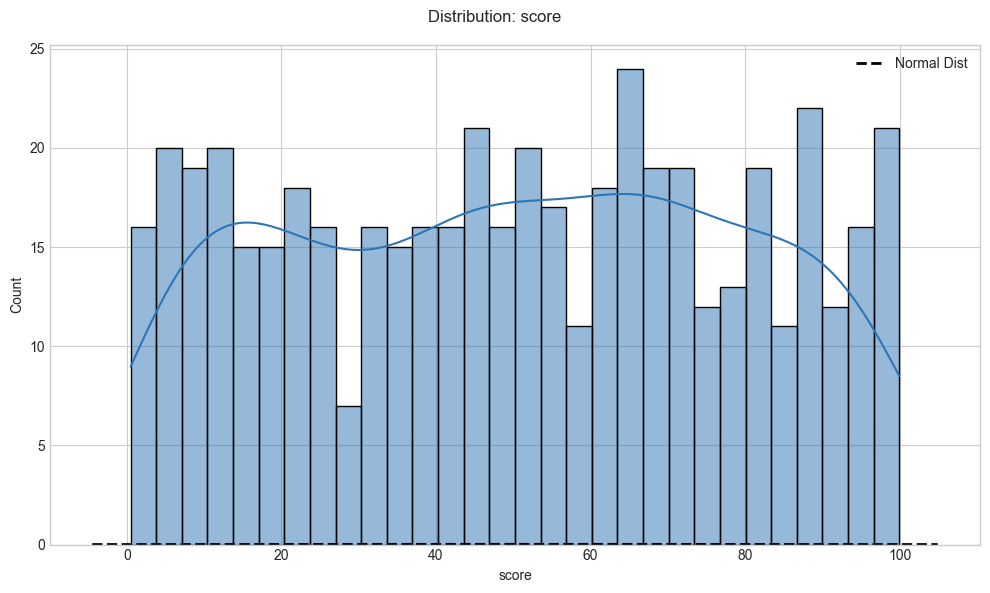

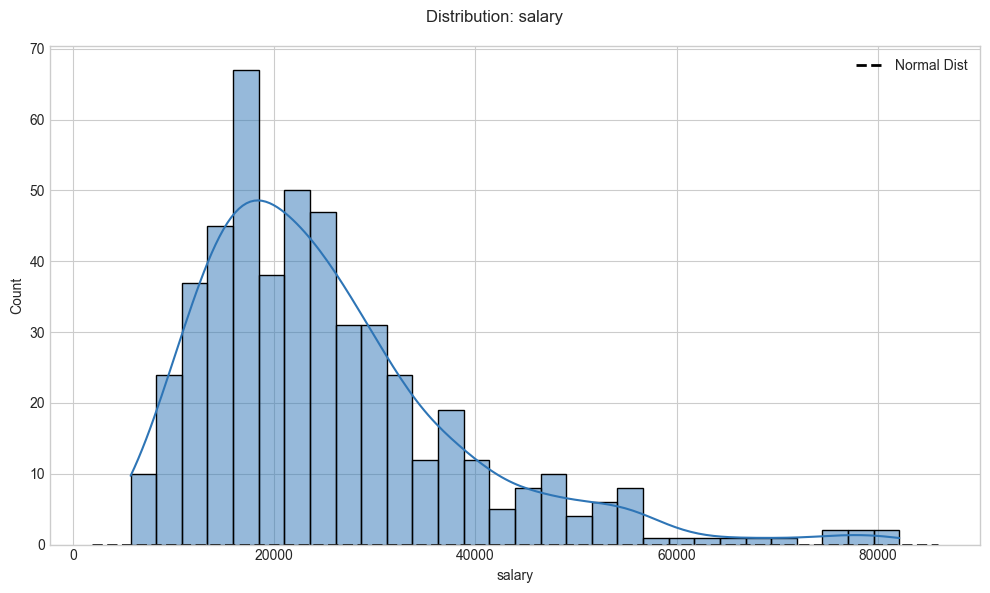

<Figure size 640x480 with 0 Axes>

In [3]:
from ds_engine.exploration import summary, distributions

# Summary stats
stats_data, _ = summary.run(df, columns=['age', 'salary'], params={})
print('Summary Age:', stats_data['age'])

# Distributions
dist_data, dist_plots = distributions.run(df, columns=['salary', 'score'], params={'plot_type': 'both', 'show_normal_overlay': True})
for fig in dist_plots:
    plt.figure(fig.number)
    plt.show()


### 3. Correlations


[2026-03-24 20:28:32] [WARNING] [ds_engine] correlations skipped non-numeric columns: ['group']


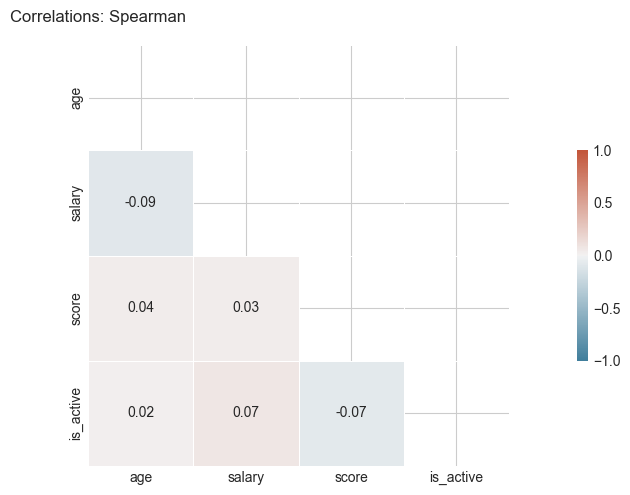

In [4]:
from ds_engine.exploration import correlations

corr_data, corr_plots = correlations.run(df, columns=[], params={'method': 'spearman'})
for fig in corr_plots:
    plt.figure(fig.number)
    plt.show()


### 4. Statistical Hypothesis Testing


In [5]:
from ds_engine.statistics import hypothesis

# Test if 'age' differs across 'group' using ANOVA
test_data, _ = hypothesis.run(df, columns=['age'], params={'test': 'anova', 'group_column': 'group'})
print('ANOVA Results:', test_data)


ANOVA Results: {'age': {'test_name': 'anova', 'statistic': 1.0139078886181114, 'p_value': 0.36354759008386955, 'alpha': 0.05, 'reject_null': False, 'interpretation': "No significant difference in 'age'"}}
